<a href="https://colab.research.google.com/github/sophiamg0228/Integracion-de-datos-y-prospectiva/blob/main/Integraci%C3%B3n_multidimensional_Sophia_y_Manuela.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Caso de estudio**

Una aseguradora de salud con cobertura nacional en los Estados Unidos necesita optimizar la organizacion y oferta de sus servicios medicos, asi como los incentivos de salud, en lugar de trasladar a los pacientes. Para ello la entidad requiere lo siguiente

- Identificar el número de clusters que pueden ser eficientes para la reorganización de la oferta de servicios médicos.

- Caracterizar las variables clínicas y los perfiles de los pacientes de acuerdo con sus variables epidemiológicas (Variables de Entrada) y de costo siniestro (Variable de Salida).

- Conocer la distribución porcentual por región y por siniestralidad (Variables Salida).

0. Se cargan las librerías de trabajo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
!pip install --upgrade pip
!pip install scikit-learn-extra
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 8.6 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2154555 sha256=bcfcdd7bb96bc4add541ad17b6d27c88bffc0938091f5f9c9068e957d5ada803
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra


1. Carga y preparación de la base de datos

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("teertha/ushealthinsurancedataset")

print("Path to dataset files:", path)

100%|██████████| 16.0k/16.0k [00:00<00:00, 23.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/teertha/ushealthinsurancedataset/versions/1


In [ ]:
import os
csv_file = os.path.join(path, "insurance.csv")
XDB2 = pd.read_csv(csv_file)
XDB2 = XDB2.dropna().reset_index(drop=True)

XDB2.head()

# Codificación de variables categóricas
XDB2['sex_code'] = XDB2['sex'].map({'female': 0, 'male': 1})
XDB2['smoker_code'] = XDB2['smoker'].map({'no': 0, 'yes': 1})

# Definición de variables de entrada (clínicas/epidemiológicas) y salida (región y costo)
var_entrada = ['age', 'bmi', 'children', 'smoker_code', 'sex_code']
var_salida = ['region', 'charges']

,age,sex,bmi,children,smoker,region,charges,sex_code,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,0,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0


In [ ]:
# Matriz solo con variables de entrada
XDB = XDB2[var_entrada].copy()

display(XDB2.head())

,age,sex,bmi,children,smoker,region,charges,sex_code,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,0,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0


2. Se analiza y selecciona el K adecuado

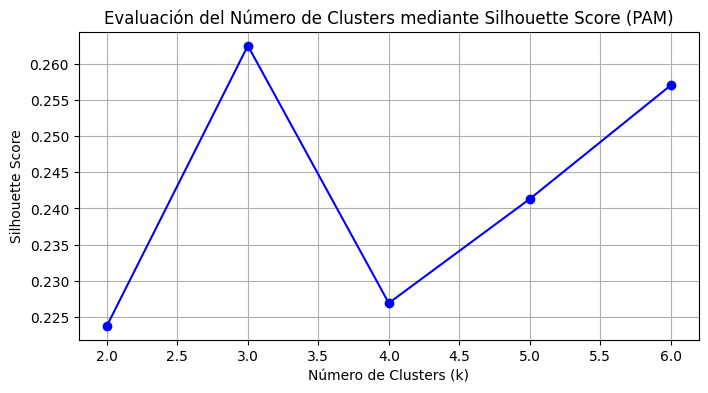

Número de clusters seleccionados como eficientes: 3


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(XDB)

silhouette_scores = []
k_range = range(2, 7)

for k in k_range:
    kmedoids = KMedoids(n_clusters=k, metric='euclidean', random_state=42, method='pam')
    kmedoids.fit(X_scaled)
    score = silhouette_score(X_scaled, kmedoids.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.title('Evaluación del Número de Clusters mediante Silhouette Score (PAM)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

k_optimo = k_range[np.argmax(silhouette_scores)]
print(f"Número de clusters seleccionados como eficientes: {k_optimo}")

3. Entrenamiento de KMedoids

In [ ]:
kmedoids_final = KMedoids(n_clusters=k_optimo, metric='euclidean', random_state=42, method='pam')
kmedoids_final.fit(X_scaled)

# Asignación de etiqueta de cluster
XDB2['Cluster'] = kmedoids_final.labels_

4. Caracterización de los pacientes

In [ ]:
# Obtención de los Medoides Reales (puntos representativos reales del dataset)
medoides_indices = kmedoids_final.medoid_indices_
df_medoides = XDB2.iloc[medoides_indices].copy()

print("MEDOIDES REPRESENTATIVOS DE CADA CLÚSTER")
display(df_medoides)

# Caracterización promedio de los clústeres
perfil_clusters = XDB2.groupby('Cluster').agg({
    'age': 'mean',
    'bmi': 'mean',
    'children': 'mean',
    'smoker_code': lambda x: f"{(x.mean()*100):.1f}%", # Porcentaje de fumadores
    'charges': ['mean', 'median', 'std']
}).reset_index()

print("CARACTERIZACIÓN DE VARIABLES CLINICAS Y SINIESTRALIDAD")
display(perfil_clusters)

MEDOIDES REPRESENTATIVOS DE CADA CLÚSTER


,age,sex,bmi,children,smoker,region,charges,sex_code,smoker_code,Cluster
922,38,male,31.000,1,no,southwest,5488.26200,1,0,0
669,40,female,29.810,1,no,southeast,6500.23590,0,0,1
1278,39,male,29.925,1,yes,northeast,22462.04375,1,1,2


CARACTERIZACIÓN DE VARIABLES CLINICAS Y SINIESTRALIDAD


Cluster        age        bmi  children smoker_code       charges  \
                mean       mean      mean    <lambda>          mean   
0       0  39.061896  30.770580  1.092843        0.0%   8087.204731   
1       1  39.691042  30.539525  1.087751        0.0%   8762.297300   
2       2  38.514599  30.708449  1.113139      100.0%  32050.231832   

                              
        median           std  
0   6985.50695   5908.108989  
1   7639.41745   6060.775970  
2  34456.34845  11541.547176

5. Distribución porcentual y territorial


--- DISTRIBUCIÓN PORCENTUAL POR REGIÓN (%) ---


region,northeast,northwest,southeast,southwest
Cluster,,,,
0,24.18,25.53,25.92,24.37
1,24.13,24.68,25.41,25.78
2,24.45,21.17,33.21,21.17


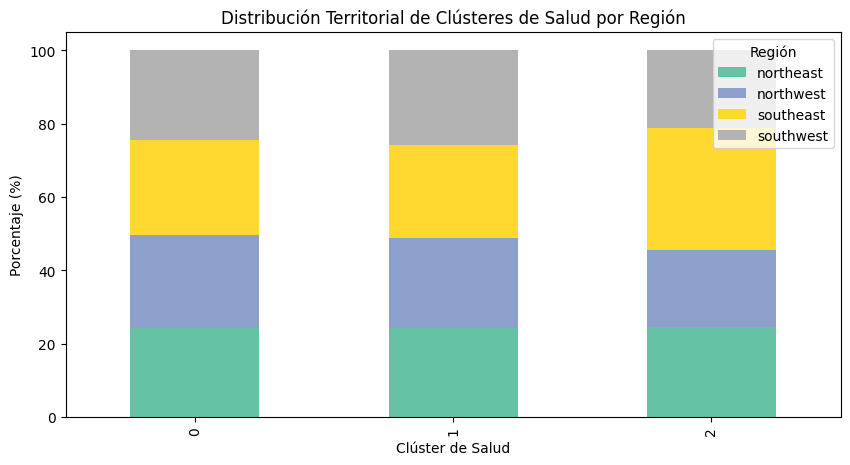


--- RESUMEN DE SINIESTRALIDAD POR REGIÓN Y CLÚSTER ---


,region,Cluster,count,mean,sum
0,northeast,0,125,8664.042222,1.083005e+06
1,northeast,1,132,9640.426984,1.272536e+06
2,northeast,2,67,29673.536473,1.988127e+06
3,northwest,0,132,8320.689321,1.098331e+06
4,northwest,1,135,8786.998679,1.186245e+06
5,northwest,2,58,30192.003182,1.751136e+06
6,southeast,0,134,7609.003587,1.019606e+06
7,southeast,1,139,8440.205552,1.173189e+06
8,southeast,2,91,34844.996824,3.170895e+06
9,southwest,0,126,7778.905534,9.801421e+05


In [ ]:
# Distribución Porcentual por Región
dist_region = pd.crosstab(XDB2['Cluster'], XDB2['region'], normalize='index') * 100
print("\n--- DISTRIBUCIÓN PORCENTUAL POR REGIÓN (%) ---")
display(dist_region.round(2))

# Gráfico de distribución territorial
dist_region.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2')
plt.title('Distribución Territorial de Clústeres de Salud por Región')
plt.xlabel('Clúster de Salud')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Región')
plt.show()

# Distribución de Siniestralidad por Región y Clúster
siniestralidad = XDB2.groupby(['region', 'Cluster'])['charges'].agg(['count', 'mean', 'sum']).reset_index()
print("\n--- RESUMEN DE SINIESTRALIDAD POR REGIÓN Y CLÚSTER ---")
display(siniestralidad.head(12))

# **Analisis de resultados**

Para objetivo del proyecto una vez realizado todo el procesamiento de datos, podemos concluir los siguientes resultados de acuerdo al caso planteado al incio de este documento.

1. El numero de clusters mas adecuado y efectivo para la reorganizacion de la oferta de servicios medicos son 3 clusters

2. Caracterizacion de variables clinicas y perfil de los paciente en cada uno de los 3 clusters

- Cluster 0: En este cluster se encuentran pacientes con una edad promedio de 39 años y el BMI mas alto de los clusters de 30.77, en este cluster los fumadores son casi 0% y los costos de siniestralidad son los mas bajos 8087.20 y tienen mayor presencia en la region southeast, donde representan casi el 26% de la region

- Cluster 1: Se caracterizaa por tener a los pacientes con edad promedio mayor (casi 40 años)y el BMI mas bajo 30.53, y tambien con porcentaje de fumadores nulo 0%, tiene un costo de siniestralidad  de 8762.29. Y tienen mayor presencia en la region southwest donde representan casi el 26% de la misma

- Cluster 2: Este cluster se caracteriza por tener los paciente de menor edad (38 años en un promedio) y un BMI de 30.70, en esta cluster se encuentran el 100% de fumadores y cuenta con el costo de siniestralidad mas alto 32050.23 y tiene mayor presencia en la region southeast donde representan casi 33% porciento de la misma

3. Ahora bien la siniestralidad por region y cluster es:

- Northeast:

    - **cluster 0**: 24.18%, costo promedio: 8664.04
    - **Cluster 1**: 24.13%, costo promedio: 9640
    - **Cluster 2**: 24.45%, costo promedio: 29,673

  *Importante*:  el cluster 2 es el que tiene mas presencia y mas costo de siniestralidad

- Northwest:

    - **cluster 0**: 25.53%, costo promedio: 8320.68
    - **Cluster 1**: 24.68%, costo promedio: 8786.99
    - **Cluster 2**: 21.17%, costo promedio: 30,192.00

  *Importante*:  el cluster 2 es el que tiene menos presencia pero mas costo de siniestralidad

- Southeast:

    - **cluster 0**: 25.92%, costo promedio: 7609.00
    - **Cluster 1**: 25.41%, costo promedio: 8440.20
    - **Cluster 2**: 33.21%, costo promedio: 34,844.99

  *Importante*:  el cluster 2 es el que tiene mas presencia y mas costo de siniestralidad

- Southwest:

    - **cluster 0**: 24.37%, costo promedio: 7778.90
    - **Cluster 1**: 25.78%, costo promedio: 8234.09
    - **Cluster 2**: 21.17%, costo promedio: 32,269.06


**Concluison final** la entidad debe prestar mayor cuidado y organizar planes de salud mucho mas robustos e incentivos de salud mas fuertes que incluyan campañas de salud a los pacientes del cluster 2 siendo estos pacientes los que un mayor costo de siniestralidad generan en todas las regiones, mientras que el cluster con menos costo es el cluster 0


    


